In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
#Exploratory data analysis

<Axes: xlabel='count', ylabel='Gender'>

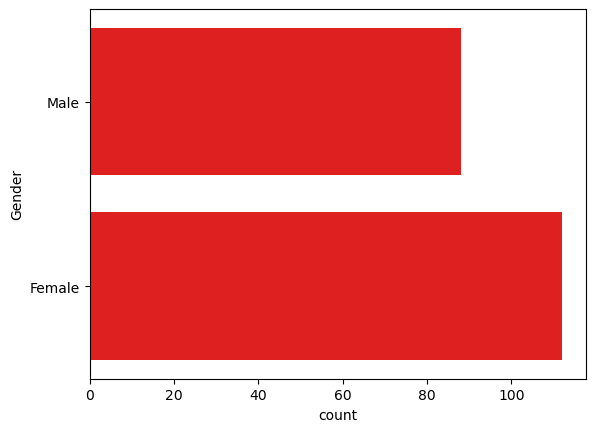

In [7]:
sns.countplot(df['Gender'],color='red')

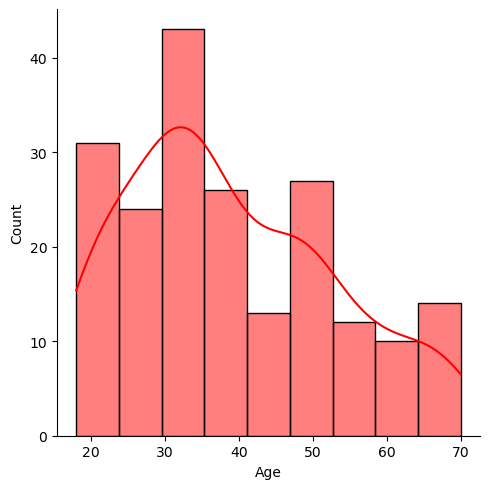

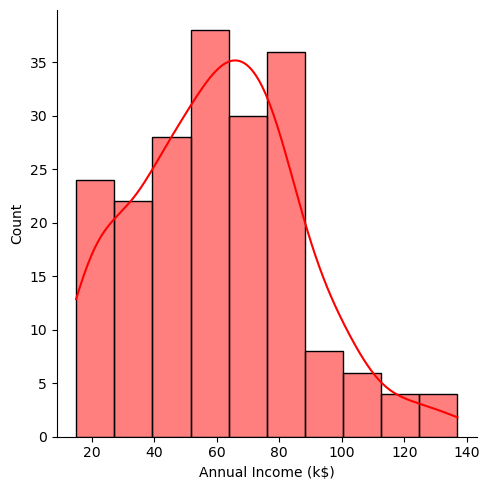

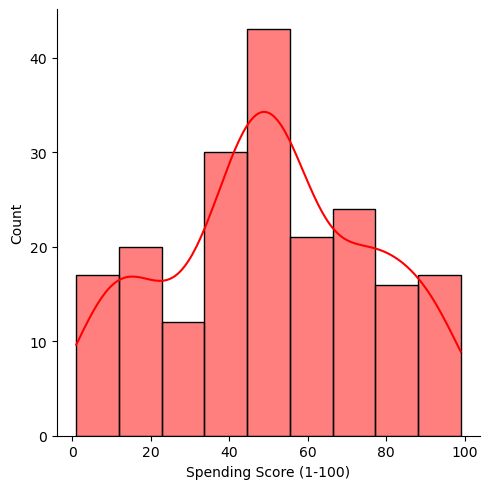

In [8]:
#plot histogram
cols=['Age','Annual Income (k$)','Spending Score (1-100)']
for col in cols:
    sns.displot(df[col],color='red',kde=True)

<Axes: >

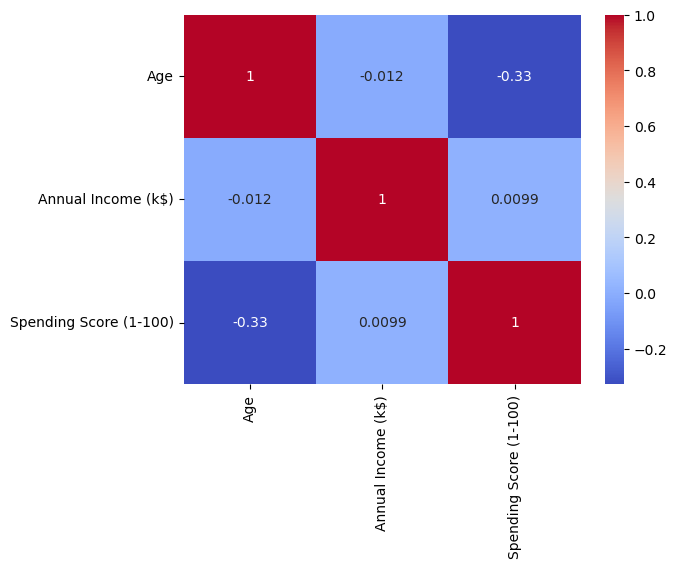

In [9]:
corr=df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [10]:
#KMEANS CLUSTERING(2 FEATURES)
X= df[['Annual Income (k$)', 'Spending Score (1-100)']]

from sklearn.cluster import KMeans



In [11]:

wcss = []

for i in range(1,11):
    

    k_means =KMeans(n_clusters =i)

    k_means.fit(X)

    wcss.append(k_means.inertia_)

In [12]:
wcss

[269981.28,
 186362.95600651758,
 106348.37306211119,
 73880.64496247195,
 44454.47647967974,
 40825.16946386946,
 31969.426550235476,
 31462.072872522214,
 23258.317162223742,
 24199.025363014178]

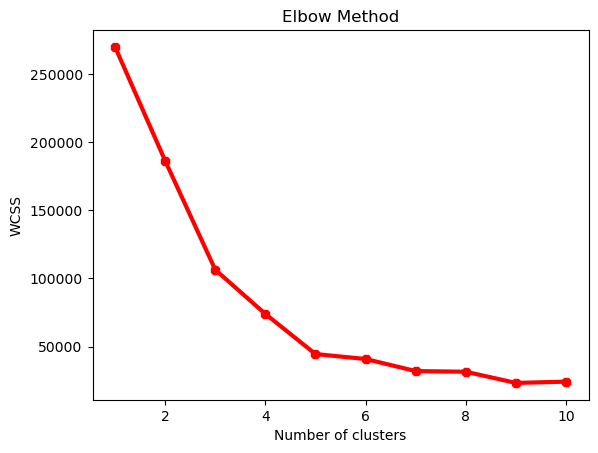

In [13]:
plt.plot(range(1,11), wcss, linewidth=3, color='red', marker='8')

plt.title('Elbow Method')

plt.xlabel('Number of clusters')

plt.ylabel('WCSS')

plt.show()

# 5 is the best value for k


In [14]:
k_means=KMeans(n_clusters=5,random_state=42)
y_means=k_means.fit_predict(X)

In [15]:
y_means

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

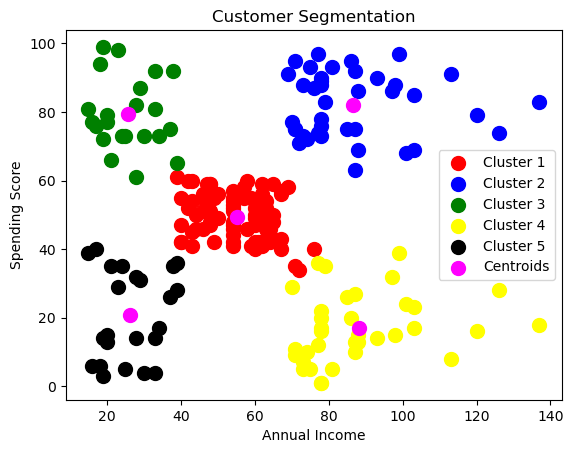

In [16]:
plt.scatter(X.iloc[y_means == 0, 0], X.iloc[y_means == 0, 1], s = 100, c='red' ,label='Cluster 1')
plt.scatter(X.iloc[y_means == 1, 0], X.iloc[y_means == 1, 1], s= 100, c='blue', label='Cluster 2')
plt.scatter(X.iloc[y_means == 2, 0], X.iloc[y_means == 2, 1], s = 100 ,c='green' ,label='Cluster 3')
plt.scatter(X.iloc[y_means == 3, 0],X.iloc[y_means == 3, 1], s = 100 ,c='yellow' ,label='Cluster 4')
plt.scatter(X.iloc[y_means == 4, 0],X.iloc[y_means == 4, 1], s = 100 ,c='black' ,label='Cluster 5')
plt.scatter(k_means.cluster_centers_[:,0],k_means.cluster_centers_[:,1],s = 100 , c='magenta' ,label='Centroids')
plt.title('Customer Segmentation')

plt.xlabel('Annual Income')

plt.ylabel('Spending Score')

plt.legend()

plt.show()

In [17]:
k_means.predict([[10,15]])

array([4], dtype=int32)

In [22]:
#DBSCAN

In [23]:
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler

X= df[['Annual Income (k$)', 'Spending Score (1-100)']]

x_scaled =StandardScaler().fit_transform(X)

In [24]:
dbscan=DBSCAN(eps=0.40,min_samples=3)
labels=dbscan.fit_predict(x_scaled)

In [25]:
df['Clusters']=labels

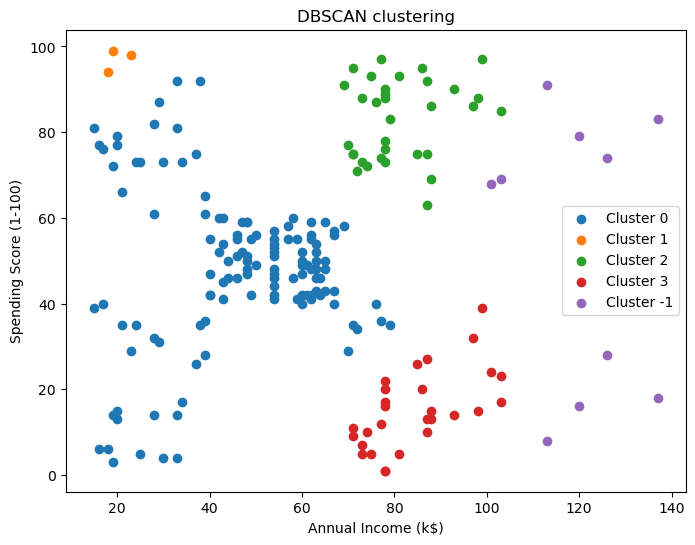

In [26]:
#plot the clusters
plt.figure(figsize=(8,6))

for cluster in set(labels):
    

    plt.scatter(X.iloc[labels == cluster, 0], X.iloc[labels == cluster, 1], label = f"Cluster {cluster}")

    plt.title("DBSCAN clustering")

    plt.xlabel("Annual Income (k$)")

    plt.ylabel("Spending Score (1-100)")

    plt.legend()

    plt.show

In [27]:
# lets  save the model

In [28]:
import pickle
pickle.dump(k_means,open('k_means.pickle','wb'))